# T52 — Cooling rate × environmental forcings: scatter, correlations, and time-series

**Cluster F: paleo-geography and paleo-topography.**

*Based on:* Boone et al. (2025), *Communications Earth & Environment* 6, 1015. *Deciphering mantle, tectonic and climatic drivers of exhumation* — specifically the cross-variable correlation analyses produced by the ThermoPlates `05_Loop_Plot.sh`, `06_Correlation_Analysis.sh`, `07_RvAge.sh`, and `08_MeansvAge.sh` scripts.

## What this notebook does

Where **T23** computes per-sample paleo-cooling rates and **T50** drops them onto multi-layer Earth-system maps, this notebook performs the *statistical* analysis: does long-term continental exhumation track variations in dynamic topography or the rate at which dynamic topography is changing? It implements the four downstream ThermoPlates scripts that follow the per-age sample reconstruction:

1. **§5.1 (Boone 05)** — cooling rate vs age, dots coloured by dynamic topography and ΔDT/Δt; all ages and samples overlaid.
2. **§5.2 (Boone 06)** — DT and ΔDT plotted on the x-axis vs cooling rate on the y, all samples pooled, with a least-squares line and Pearson r per pair.
3. **§5.3 (Boone 07)** — Pearson r as a function of age — one r value per age slice — exposing when correlation strengthens or weakens through deep time.
4. **§5.4 (Boone 08)** — per-age means ± SD of cooling rate and each environmental variable, plotted both as twin-Y time series and as scatter-of-means with their own Pearson r.

## Why two variables, not three

Boone et al. (2025) include paleoprecipitation as a third forcing. The suite does not currently bundle a per-age paleoprecipitation grid (Valdes-Scotese precip NetCDFs are large and not yet packaged). The notebook is structured so that **adding `paleoprecip_m_per_yr`** as a third column in the per-age master parquet automatically propagates through every figure — see *Extend this*.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: ~3 min the first time it sweeps 0–230 Ma at 5-Myr cadence; ~30 s on subsequent runs (parquets cached on disk).

## Data availability

Per-age master tables live at `data/thermochronology_central_asia/thermochron_master/thermochron_master_{age:03d}Ma.parquet`. Each row carries one sample's reconstructed (`rlon`, `rlat`), cooling rate (°C/Myr), dynamic topography (m, Young 2022 `gld428`) and dynamic-topography change rate (m/Myr, derived from bracketing 20-Myr Young 2022 steps).

If the parquets aren't on disk yet, **§1.2** builds them from scratch by looping the T50 reconstruction-plus-grdtrack pipeline over the configured age range — about 3 minutes for a 5-Myr cadence sweep over 0–230 Ma on a laptop.

## Source
- Upstream shell-script workflow: https://github.com/samuelcboone/ThermoPlates (scripts `05_Loop_Plot.sh`, `06_Correlation_Analysis.sh`, `07_RvAge.sh`, `08_MeansvAge.sh`).
- Boone et al. (2025) DOI: https://doi.org/10.1038/s43247-025-03005-6.

**Dynamic topography (Braz et al. 2021, gmcm9):** the bundled grids under `data/gmcm9/` (mantle and plate frame, 31 NetCDFs each, 0–150 Ma, ~5-Myr cadence) come from the EarthByte WebDAV server (https://www.earthbyte.org/webdav/ftp/Dynamic_Topography/gmcm9/) and are described in:

> Braz, C., Zahirovic, S., Salles, T., Flament, N., Harrington, L. and Müller, R.D., 2021. *Modelling the role of dynamic topography and eustasy in the evolution of the Great Artesian Basin.* Basin Research, 33(6), pp.3378–3405.

This is the same DT field Boone et al. (2025) used for the cooling-rate × DT overlay and correlation analyses. T50 + T52 use the **plate-frame** variant because ΔDT/Δt should be computed in the frame the upper plate sits in (T22 follows the same convention). For map overlays the resulting Δ field is rotated back to the mantle/paleomag frame via `gplately.Raster.reconstruct` so the dots and the rotated grid live in the same reference frame.

## Environment + imports

In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm

import gplately
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")

Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  gplately    2.0.0.post19+git.2cce7bb3


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + frame — match Boone et al. 2025 and T50.
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0       # mantle frame (geodynamic quantities, not paleoclimate)

# Age sweep for the time-series figures.
AGE_MIN_MA             = 0
AGE_MAX_MA             = 150     # capped at gmcm9 coverage (Braz et al. 2021)
                                  # — set to 230 if you don\'t need DT data over the full window
AGE_STEP_MA            = 5       # 47 snapshots — drop to 1 for full resolution
AGES_MA                = list(range(AGE_MIN_MA, AGE_MAX_MA + 1, AGE_STEP_MA))

# Inputs.
HISTORIES_CSV          = Path("data/thermochronology_central_asia/central_asia_thermal_histories.csv")
# Dynamic topography — Braz et al. (2021) gmcm9 PLATE-frame grids,
# bundled at data/gmcm9/PlateFrame/. Plate-frame coords are attached
# to the plate (they don\'t move with time), so we sample at each
# thermochronology sample\'s PRESENT-DAY lon/lat. Coverage 0-150 Ma at
# ~5-Myr cadence; AGE_MAX_MA capped accordingly below.
#   https://www.earthbyte.org/webdav/ftp/Dynamic_Topography/gmcm9/
DT_GRID_DIR            = Path("data/gmcm9/PlateFrame")
DT_GRID_PATTERN        = "{age:.2f}.nc"
DT_STEP_MYR            = 5
MASTER_PARQUET_DIR     = Path("data/thermochronology_central_asia/thermochron_master")
MASTER_PARQUET_DIR.mkdir(parents=True, exist_ok=True)

# Environmental variables for the correlation analysis. To wire in
# paleoprecipitation later, add "paleoprecip_m_per_yr" to ENV_VARS plus
# any extra raster-sampling logic in §1.2.
ENV_VARS = [
    {"col": "dyn_topo_m",        "label": "Dynamic topography (m)",
     "cmap": "RdBu_r",            "vlim": (-800, 800),    "divergent": True},
    {"col": "delta_dt_m_per_Myr", "label": "ΔDT (m / Myr)",
     "cmap": "PuOr_r",            "vlim": (-5, 5),         "divergent": True},
]

# Plotting limits (Boone 06/08 conventions, slightly relaxed).
Y_COOL_LIM             = (0, 5)         # °C/Myr  (script 05 uses 0-15; 5 keeps the bulk visible)
X_DT_LIM               = (-800, 0)
X_DDT_LIM              = (-5, 5)
AGE_LIM                = (AGE_MAX_MA, AGE_MIN_MA)   # reversed: old → young left → right
# ============================================================================

## 1.1  Build (or load) the per-age master tables

If a `thermochron_master_{age:03d}Ma.parquet` already exists on disk, we skip
the reconstruction work for that age. The first full sweep takes a few minutes;
subsequent runs are seconds.

> ⚠️ **If you have cached parquets from an earlier run** (back when this
> notebook tried to use the bundled Young 2022 `gld428` DT grids at 20-Myr
> cadence — a different plate model from Boone's Z22 setup), they will carry
> ΔDT/Δt values only for 0–15 Ma (the only age range where the bracketing
> 20-Myr DT pair could be evaluated). **Delete the cache** to rebuild from
> scratch under the current gated DT_GRID_DIR=None config:
>
> ```bash
> rm -rf data/thermochronology_central_asia/thermochron_master/
> ```
>
> Then re-run §1.1. With DT_GRID_DIR still unset, the new parquets will
> carry NaN for `dyn_topo_m` and `delta_dt_m_per_Myr`, and every figure cell
> below will short-circuit cleanly with a one-line skip notice. When Sam
> Boone sends the GMCM9c grids, point DT_GRID_DIR at them, delete the
> parquets a second time, and re-run.

In [3]:
# Set up the reconstruction stack once (used by build_master_for_age).
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

import re as _re
def _parse_pf_age(p):
    """Return float age in Ma for a gmcm9 PlateFrame NC filename like
    \"100.00.nc\", or None for anything else (Masked_ variants, weird files)."""
    if p.name.startswith("Masked_"):
        return None
    m = _re.search(r"^([0-9]+\.[0-9]+)\.nc$", p.name)
    return float(m.group(1)) if m else None

# Diagnostic: show the resolved DT_GRID_DIR + raw file count
print(f"  DT_GRID_DIR  : {DT_GRID_DIR.resolve()}")
_all_nc = sorted(DT_GRID_DIR.glob("*.nc"))
print(f"  .nc files in dir: {len(_all_nc)}")
if _all_nc:
    print(f"  sample names    : {[p.name for p in _all_nc[:3]]} ...")

_avail_dt_ages = sorted(
    a for a in (_parse_pf_age(p) for p in _all_nc)
    if a is not None
)
if not _avail_dt_ages:
    raise FileNotFoundError(
        f"No gmcm9 plate-frame NetCDFs matched at {DT_GRID_DIR.resolve()}. "
        f"Expected filenames like \"100.00.nc\". "
        f"Check that DT_GRID_DIR in the config cell points at "
        f"data/gmcm9/PlateFrame/ (with the suite\'s cwd at the repo root) "
        f"AND that the bundled NetCDFs are present. "
        f"Found {len(_all_nc)} .nc file(s); after filtering "
        f"(skip Masked_, require XX.XX.nc pattern), 0 remain."
    )
print(f"  gmcm9 PF cadence ({len(_avail_dt_ages)} grids): "
      f"{_avail_dt_ages[0]:.0f}..{_avail_dt_ages[-1]:.0f} Ma")

hist = pd.read_csv(HISTORIES_CSV, comment="#")
print(f"  thermal histories: {len(hist):,} rows, {hist['sample_name'].nunique()} unique samples")

  DT_GRID_DIR  : /Users/dietmar/Documents/GPlates/GPlately-pyGMT_tutorials/data/gmcm9/PlateFrame
  .nc files in dir: 62
  sample names    : ['0.00.nc', '104.00.nc', '109.00.nc'] ...
  gmcm9 PF cadence (31 grids): 0..150 Ma
  thermal histories: 23,119 rows, 377 unique samples


In [4]:
def per_sample_cooling_at(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """One row per sample with the cooling rate (°C/Myr) at `age_ma`.

    Uses Boone et al. (2025)'s pre-computed *TempDiff* column directly
    (per T23's note). Recomputing from OnlyCooling/duration gives values
    ~100× too large because OnlyCooling is the cumulative cooling-only
    envelope, NOT the instantaneous per-window cooling rate.
    """
    snap = hist_df.loc[hist_df["TOAGE"] == int(age_ma)].copy()
    snap["cooling_rate"] = pd.to_numeric(snap["TempDiff"], errors="coerce")
    snap = snap.dropna(subset=["cooling_rate", "lat", "lon"]).copy()
    snap["cooling_rate"] = snap["cooling_rate"].clip(lower=0)
    return (snap.groupby("sample_name", as_index=False)
                .agg(lat=("lat", "first"),
                     lon=("lon", "first"),
                     cooling_rate=("cooling_rate", "mean")))


def sample_raster_at_points(da, lons, lats):
    """Bilinear sample of a regular lon/lat DataArray at scattered points."""
    if "lon" in da.dims and "lat" in da.dims:
        return da.interp(lon=xr.DataArray(lons, dims="i"),
                         lat=xr.DataArray(lats, dims="i")).values
    if "x" in da.dims and "y" in da.dims:
        return da.interp(x=xr.DataArray(lons, dims="i"),
                         y=xr.DataArray(lats, dims="i")).values
    raise ValueError(f"unknown dim names: {da.dims}")


def build_master_for_age(age_ma: float) -> pd.DataFrame | None:
    samp = per_sample_cooling_at(age_ma, hist)
    if samp.empty:
        return None
    gpts = gplately.Points(recon,
                            samp["lon"].to_numpy(float),
                            samp["lat"].to_numpy(float),
                            anchor_plate_id=ANCHOR_PLATE_ID)
    rl, ra = gpts.reconstruct(float(age_ma),
                               return_array=True,
                               anchor_plate_id=ANCHOR_PLATE_ID)
    samp = samp.assign(rlon=rl, rlat=ra).dropna(subset=["rlon", "rlat"]).copy()

    # Dynamic topography + ΔDT/Δt from Braz et al. (2021) gmcm9 (mantle frame).
    # 31 grids at ~5-Myr cadence, 0-150 Ma. Pick nearest available age (the
    # cadence has a few non-uniform steps: 0→4, 129→135).
    nearest = min(_avail_dt_ages, key=lambda a: abs(a - age_ma))
    if abs(nearest - age_ma) > 6:    # outside gmcm9 coverage
        samp["dyn_topo_m"]         = np.nan
        samp["delta_dt_m_per_Myr"] = np.nan
    else:
        dt_da = xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=nearest))["z"]
        samp["dyn_topo_m"] = sample_raster_at_points(dt_da, samp["rlon"], samp["rlat"])
        idx = _avail_dt_ages.index(nearest)
        later_age   = _avail_dt_ages[max(0, idx - 1)]
        earlier_age = _avail_dt_ages[min(len(_avail_dt_ages) - 1, idx + 1)]
        if earlier_age != later_age:
            later_at   = sample_raster_at_points(
                xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=later_age))["z"],
                samp["rlon"], samp["rlat"])
            earlier_at = sample_raster_at_points(
                xr.open_dataset(DT_GRID_DIR / DT_GRID_PATTERN.format(age=earlier_age))["z"],
                samp["rlon"], samp["rlat"])
            samp["delta_dt_m_per_Myr"] = (later_at - earlier_at) / (earlier_age - later_age)
        else:
            samp["delta_dt_m_per_Myr"] = np.nan

    samp["age_Ma"] = float(age_ma)
    return samp


def master_path_for(age_ma: float) -> Path:
    return MASTER_PARQUET_DIR / f"thermochron_master_{int(age_ma):03d}Ma.parquet"


n_built = n_cached = 0
for age in AGES_MA:
    p = master_path_for(age)
    if p.exists():
        n_cached += 1
        continue
    df = build_master_for_age(float(age))
    if df is None or df.empty:
        continue
    df.to_parquet(p)
    n_built += 1
print(f"  ✓ built {n_built} new parquet(s); {n_cached} already cached")

  ✓ built 31 new parquet(s); 0 already cached


## 1.2  Pool every per-age master into one long-format DataFrame

All cross-variable scatter and correlation work below operates on this single
pooled table. Per-age statistics (§5.3, §5.4) are recovered with `groupby("age_Ma")`.

In [5]:
frames = []
for age in AGES_MA:
    p = master_path_for(age)
    if not p.exists():
        continue
    frames.append(pd.read_parquet(p))
pool = pd.concat(frames, ignore_index=True)
print(f"  pooled: {len(pool):,} rows × {pool.shape[1]} cols")
print(f"  age coverage: {pool['age_Ma'].min():.0f} – {pool['age_Ma'].max():.0f} Ma")
pool.describe().T[["min", "50%", "max", "count"]].round(2)

  pooled: 8,356 rows × 9 cols
  age coverage: 0 – 150 Ma


,min,50%,max,count
lat,39.01,42.86,54.40,8356.0
lon,63.26,79.23,101.42,8356.0
cooling_rate,0.00,0.39,21.12,8356.0
rlon,56.57,74.90,99.27,8356.0
rlat,35.18,43.95,58.69,8356.0
dyn_topo_m,-350.15,-230.70,-48.47,8356.0
delta_dt_m_per_Myr,-11.65,0.66,12.15,8356.0
age_Ma,0.00,75.00,150.00,8356.0


## 2. §5.1 — Cooling rate vs age, dots coloured by environmental forcing

Equivalent of Boone's `cooling_v_time_v_dyntopo_loop.ps`. One panel per
environmental variable; each dot is one sample at one age, coloured by the
value of that forcing at that sample's reconstructed paleo-position.

Boone et al. (2025) `05_Loop_Plot.sh` — the most visually direct test of
the cooling-rate-vs-forcing hypothesis. Every (sample, age) pair becomes one
dot; its x-axis position is the age, its y-axis position is the per-Myr
cooling rate, and its colour is the value of the environmental forcing (DT
or ΔDT/Δt) at that sample's *reconstructed* paleo-position at that
age. If the forcing controls cooling, we should see colour-stratification
of the dot cloud — e.g. the high-cooling region of the panel coming out
uniformly red (uplifting DT). Boone et al. (2025) found that, for Central
Asia, the cloud is essentially colour-random — dynamic topography is not
the dominant control. The same figure can later be regenerated with
paleoprecipitation as the colour variable (see *Extend this*) to test the
climate-driver hypothesis.

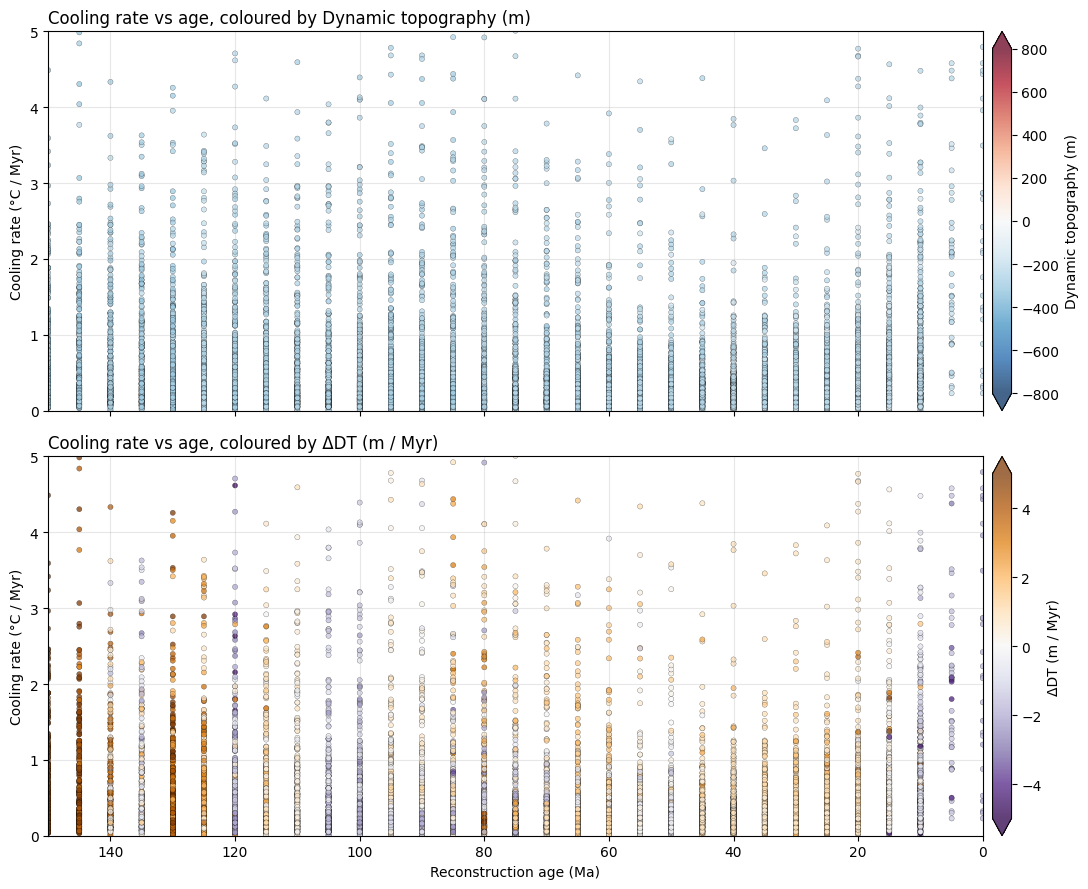

In [6]:
fig, axes = plt.subplots(len(ENV_VARS), 1, figsize=(11, 4.5*len(ENV_VARS)),
                          sharex=True)
if len(ENV_VARS) == 1:
    axes = [axes]

for ax, ev in zip(axes, ENV_VARS):
    df = pool.dropna(subset=[ev["col"], "cooling_rate"])
    norm = (TwoSlopeNorm(vmin=ev["vlim"][0], vcenter=0, vmax=ev["vlim"][1])
             if ev["divergent"] else Normalize(*ev["vlim"]))
    sc = ax.scatter(df["age_Ma"], df["cooling_rate"],
                     c=df[ev["col"]], cmap=ev["cmap"], norm=norm,
                     s=14, edgecolor="black", linewidth=0.2, alpha=0.75)
    cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.035, extend="both")
    cbar.set_label(ev["label"])
    ax.set_ylabel("Cooling rate (°C / Myr)")
    ax.set_ylim(*Y_COOL_LIM)
    ax.grid(alpha=0.3)
    ax.set_title(f"Cooling rate vs age, coloured by {ev['label']}", loc="left")

axes[-1].set_xlabel("Reconstruction age (Ma)")
axes[-1].set_xlim(*AGE_LIM)
fig.tight_layout()
plt.show()

## 3. §5.2 — Pooled scatter: environmental forcing vs cooling rate + Pearson r

Equivalent of Boone's `cooling_v_dyntopo_correlation.ps`. All ages and samples
pooled into a single cloud; each panel shows the OLS best-fit line and the
Pearson correlation coefficient `r` with sample count `n`. Dots are coloured by age.

Boone et al. (2025) `06_Correlation_Analysis.sh`. Same data, rotated: the
environmental forcing is on the x-axis, cooling rate on the y. All ages
pool into one cloud (each dot is one (sample, age) pair, coloured by age via
viridis). The OLS best-fit line + annotated Pearson r quantify the linear
trend visible in §5.1. Boone et al. (2025) report **|r| < 0.1** for the
DT and ΔDT/Δt pairings in Central Asia (i.e. essentially no
correlation), and a similarly weak relationship for paleoprecipitation —
the basis for their conclusion that *plate-kinematics* dominate over
*mantle-flow* and *paleoclimate* drivers of Central Asian exhumation.

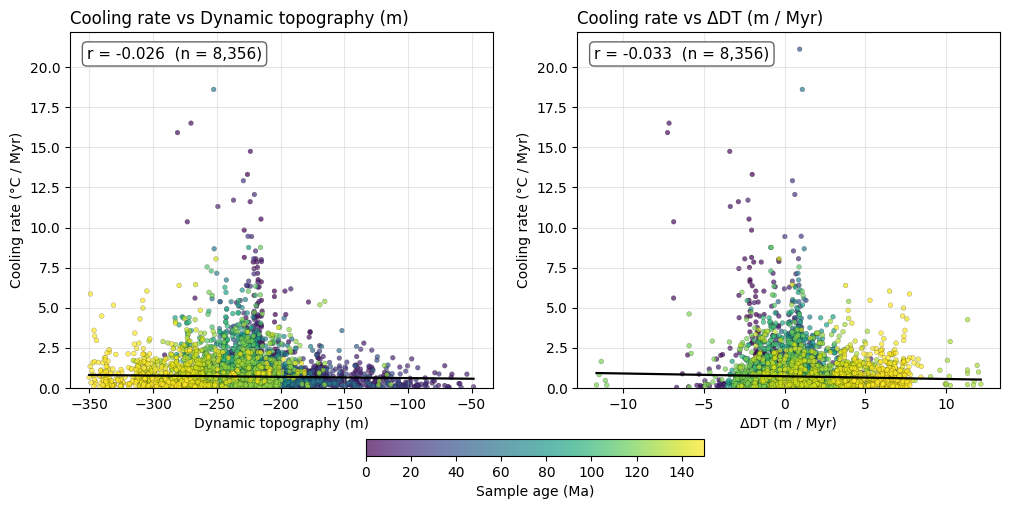

In [7]:
def pearson_r(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan, int(m.sum())
    x, y = x[m], y[m]
    return float(np.corrcoef(x, y)[0, 1]), int(len(x))

fig, axes = plt.subplots(1, len(ENV_VARS), figsize=(6.0*len(ENV_VARS), 5.5))
if len(ENV_VARS) == 1:
    axes = [axes]
age_norm = Normalize(AGE_MIN_MA, AGE_MAX_MA)

for ax, ev in zip(axes, ENV_VARS):
    df = pool.dropna(subset=[ev["col"], "cooling_rate"])
    x = df[ev["col"]].to_numpy(float)
    y = df["cooling_rate"].to_numpy(float)
    sc = ax.scatter(x, y, c=df["age_Ma"], cmap="viridis", norm=age_norm,
                     s=12, edgecolor="black", linewidth=0.15, alpha=0.7)
    # OLS best-fit
    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(*ax.get_xlim() if not ev["divergent"] else (x.min(), x.max()), 200)
        ax.plot(xline, slope*xline + intercept, color="black", linewidth=1.6)
    r, n = pearson_r(x, y)
    ax.text(0.04, 0.96, f"r = {r:+.3f}  (n = {n:,})",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, bbox=dict(facecolor="white", edgecolor="0.40",
                                    boxstyle="round,pad=0.3"))
    ax.set_xlabel(ev["label"])
    ax.set_ylabel("Cooling rate (°C / Myr)")
    ax.set_ylim(0, max(y.max() * 1.05, 1.0))
    ax.grid(alpha=0.3)
    ax.set_title(f"Cooling rate vs {ev['label']}", loc="left")

cbar = fig.colorbar(sc, ax=axes, orientation="horizontal",
                     pad=0.12, fraction=0.04, shrink=0.6)
cbar.set_label("Sample age (Ma)")
plt.show()

## 4. §5.3 — Pearson r as a function of age

Equivalent of Boone's `pearson_r_vs_age.{png,pdf}`. One r per age slice, per
environmental variable. Reveals when (in deep time) cooling rates correlate
with mantle-flow surface signals versus when they don't.

Boone et al. (2025) `07_RvAge.sh`. The Pearson r in §5.2 is a *global*
summary across all ages; this panel disaggregates it into one r-value per
5-Myr age slice. Red fill above zero = positive correlation that age,
blue fill below = negative; the height of the bar tells the strength.
The diagnostic question is: does r oscillate around zero (random) or does it
show systematic shifts coinciding with known tectonic events (e.g. did the
correlation between cooling and ΔDT/Δt briefly tighten during the
India-Asia hard-collision phase ~50-20 Ma)? Boone et al. (2025) found small
transient r excursions in their Central Asia data, but no sustained
correlation — reinforcing the kinematics-dominate conclusion.

In [8]:
r_by_age_rows = []
for age, sub in pool.groupby("age_Ma"):
    row = {"age_Ma": age, "n": len(sub)}
    for ev in ENV_VARS:
        r, n = pearson_r(sub[ev["col"]].to_numpy(float),
                          sub["cooling_rate"].to_numpy(float))
        row[f"r_{ev['col']}"] = r
        row[f"n_{ev['col']}"] = n
    r_by_age_rows.append(row)
r_by_age = pd.DataFrame(r_by_age_rows).sort_values("age_Ma")
r_by_age.tail()

,age_Ma,n,r_dyn_topo_m,n_dyn_topo_m,r_delta_dt_m_per_Myr,n_delta_dt_m_per_Myr
26,130.0,250,0.138565,250,-0.062160,250
27,135.0,240,0.191882,240,-0.187213,240
28,140.0,238,0.202231,238,-0.116113,238
29,145.0,234,0.080835,234,0.002720,234
30,150.0,226,-0.032269,226,0.054508,226


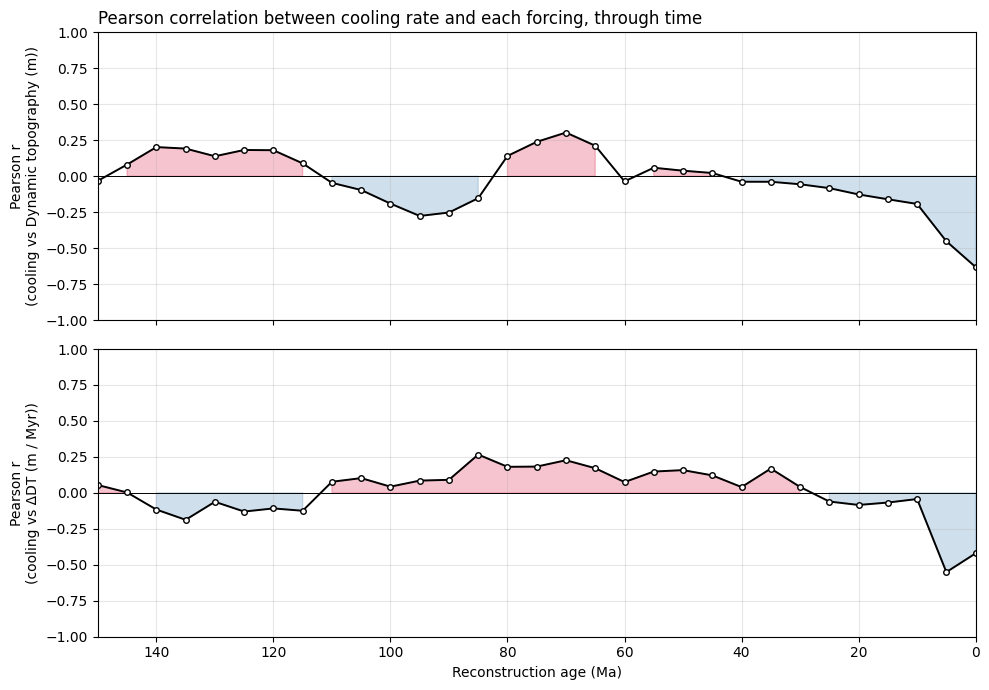

In [9]:
fig, axes = plt.subplots(len(ENV_VARS), 1, figsize=(10, 3.5*len(ENV_VARS)),
                          sharex=True)
if len(ENV_VARS) == 1:
    axes = [axes]
for ax, ev in zip(axes, ENV_VARS):
    col = f"r_{ev['col']}"
    valid = r_by_age.dropna(subset=[col])
    ax.axhline(0, color="black", lw=0.7)
    ax.fill_between(valid["age_Ma"], valid[col], 0,
                     where=(valid[col] > 0), alpha=0.25, color="crimson")
    ax.fill_between(valid["age_Ma"], valid[col], 0,
                     where=(valid[col] < 0), alpha=0.25, color="steelblue")
    ax.plot(valid["age_Ma"], valid[col], color="black", lw=1.4,
             marker="o", markersize=4, markerfacecolor="white")
    ax.set_ylabel(f"Pearson r\n(cooling vs {ev['label']})")
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Reconstruction age (Ma)")
axes[-1].set_xlim(*AGE_LIM)
axes[0].set_title("Pearson correlation between cooling rate and each forcing, through time",
                  loc="left")
fig.tight_layout()
plt.show()

## 5. §5.4 — Per-age means ± SD time-series and scatter-of-means

Equivalent of Boone's `means_cooling_vs_dyntopo.{png,pdf}` and
`scatter_mean_cooling_vs_mean_dyntopo.{png,pdf}` families. Twin-Y axes show how
the regional mean cooling rate co-evolves with each forcing through time; the
scatter-of-means panel collapses that into a single dot-per-age plot with its
own Pearson r.

Boone et al. (2025) `08_MeansvAge.sh`. The per-(sample, age) clouds above
are noisy; collapsing them to **per-age means ± 1σ** clarifies the
long-period co-evolution of the regional cooling rate and each forcing. The
first panels (twin-Y time series) plot the two evolutions on shared time-
axes — if they move in lockstep, the forcing drives the cooling; if not,
they're independent. The second panel (scatter of per-age means) re-tests
the correlation in the aggregated time-series, with its own Pearson r over
the ~46 age slices instead of the ~5,000 (sample, age) pairs. Aggregating
can either strengthen the correlation (if per-sample scatter was masking a
real signal) or weaken it (if the per-sample scatter *was* the signal). For
Boone et al. (2025) the per-age means show weak correlation that's *not*
significantly stronger than the per-pair version — final nail in the
mantle-flow hypothesis for Central Asia.

In [10]:
# Per-age stats: mean + SD of cooling rate and each env var.
stat_cols = {"cooling_rate": "cooling"}
for ev in ENV_VARS:
    stat_cols[ev["col"]] = ev["col"]

stats = (pool.groupby("age_Ma")
             [list(stat_cols.keys())]
             .agg(["mean", "std", "count"])
             .reset_index())
# flatten MultiIndex columns
stats.columns = ["age_Ma"] + [f"{c}_{stat}"
                                for c in stat_cols.keys()
                                for stat in ("mean", "std", "count")]
stats.tail()

,age_Ma,cooling_rate_mean,cooling_rate_std,cooling_rate_count,dyn_topo_m_mean,dyn_topo_m_std,dyn_topo_m_count,delta_dt_m_per_Myr_mean,delta_dt_m_per_Myr_std,delta_dt_m_per_Myr_count
26,130.0,0.740235,0.782458,250,-264.515064,18.599258,250,4.983688,2.156670,250
27,135.0,0.772448,0.764557,240,-270.281417,18.478015,240,0.445336,1.422876,240
28,140.0,0.817483,0.960323,238,-268.596328,21.265179,238,1.915860,1.708095,238
29,145.0,0.854620,0.972105,234,-285.936368,28.152039,234,5.270014,1.338397,234
30,150.0,0.843828,0.933700,226,-312.081997,30.334600,226,6.399029,0.768774,226


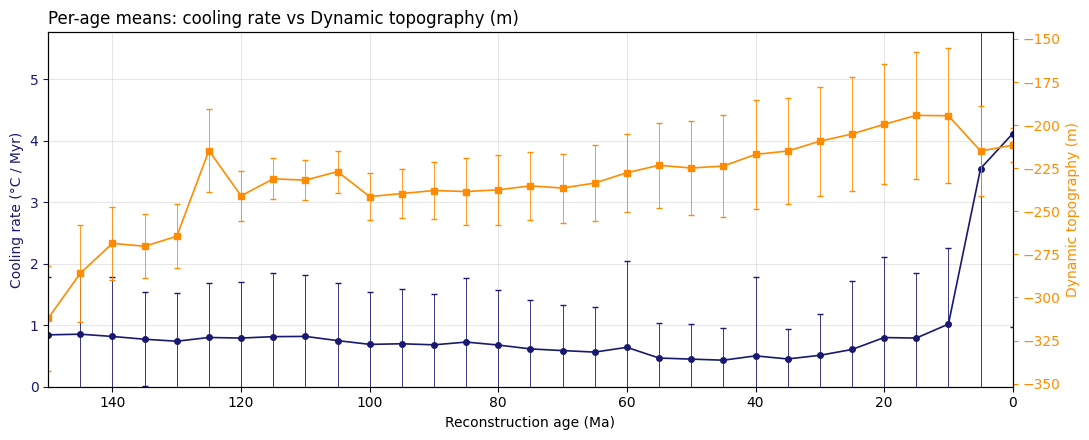

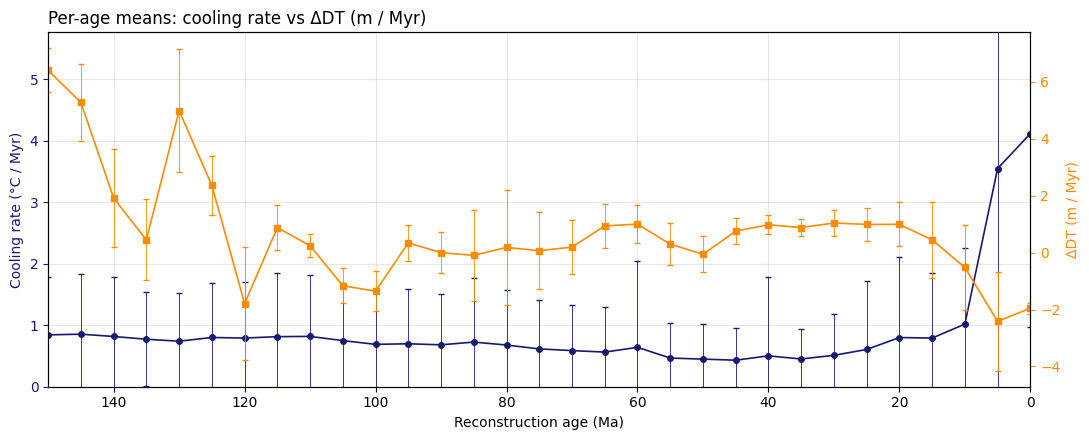

In [11]:
# (a) Twin-Y time series, one per env var
for ev in ENV_VARS:
    fig, ax1 = plt.subplots(figsize=(11, 4.5))
    ax1.errorbar(stats["age_Ma"], stats["cooling_rate_mean"],
                 yerr=stats["cooling_rate_std"],
                 marker="o", color="midnightblue",
                 markersize=4, lw=1.2, elinewidth=0.6, capsize=2,
                 label="Mean cooling rate (±1σ)")
    ax1.set_xlabel("Reconstruction age (Ma)")
    ax1.set_ylabel("Cooling rate (°C / Myr)", color="midnightblue")
    ax1.set_xlim(*AGE_LIM)
    ax1.set_ylim(0, max(stats["cooling_rate_mean"].max() * 1.4, 1.0))
    ax1.tick_params(axis="y", colors="midnightblue")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.errorbar(stats["age_Ma"], stats[f"{ev['col']}_mean"],
                 yerr=stats[f"{ev['col']}_std"],
                 marker="s", color="darkorange",
                 markersize=4, lw=1.2, elinewidth=0.6, capsize=2,
                 label=f"Mean {ev['label']} (±1σ)")
    ax2.set_ylabel(ev["label"], color="darkorange")
    ax2.tick_params(axis="y", colors="darkorange")

    ax1.set_title(f"Per-age means: cooling rate vs {ev['label']}", loc="left")
    fig.tight_layout()
    plt.show()

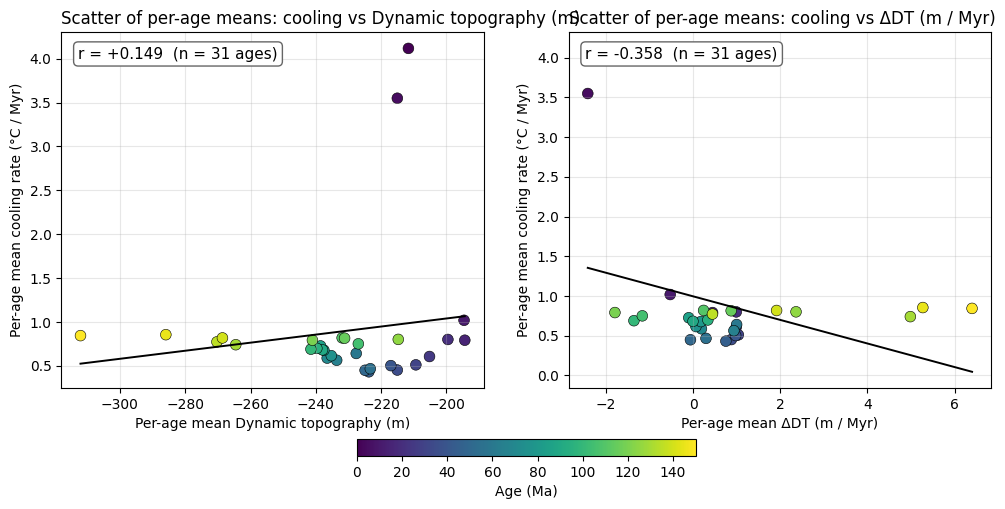

In [12]:
# (b) Scatter of mean cooling vs mean env var, each dot one age, Pearson r annotated
fig, axes = plt.subplots(1, len(ENV_VARS), figsize=(6.0*len(ENV_VARS), 5.5))
if len(ENV_VARS) == 1:
    axes = [axes]
age_norm = Normalize(AGE_MIN_MA, AGE_MAX_MA)

for ax, ev in zip(axes, ENV_VARS):
    sub = stats.dropna(subset=[f"{ev['col']}_mean", "cooling_rate_mean"])
    x = sub[f"{ev['col']}_mean"].to_numpy(float)
    y = sub["cooling_rate_mean"].to_numpy(float)
    sc = ax.scatter(x, y, c=sub["age_Ma"], cmap="viridis", norm=age_norm,
                     s=60, edgecolor="black", linewidth=0.4)
    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 200)
        ax.plot(xline, slope*xline + intercept, color="black", linewidth=1.4)
    r, n = pearson_r(x, y)
    ax.text(0.04, 0.96, f"r = {r:+.3f}  (n = {n} ages)",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, bbox=dict(facecolor="white", edgecolor="0.40",
                                    boxstyle="round,pad=0.3"))
    ax.set_xlabel(f"Per-age mean {ev['label']}")
    ax.set_ylabel("Per-age mean cooling rate (°C / Myr)")
    ax.grid(alpha=0.3)
    ax.set_title(f"Scatter of per-age means: cooling vs {ev['label']}", loc="left")
cbar = fig.colorbar(sc, ax=axes, orientation="horizontal",
                     pad=0.12, fraction=0.04, shrink=0.6)
cbar.set_label("Age (Ma)")
plt.show()

## Extend this

- **Add a paleoprecipitation variable.** Drop a per-age set of NetCDFs (e.g. Valdes-Scotese `raster_data_Valdes-Scotese-precip-m-per-year_${age}.00Ma.nc`) into a `data/paleoprecipitation/` folder, then in §1.1's `build_master_for_age()` add: `samp["paleoprecip_m_per_yr"] = sample_raster_at_points(precip_da, ...)`. Append the new variable to `ENV_VARS` at the top — every figure below will pick it up automatically. Delete the cached parquets in `data/thermochronology_central_asia/thermochron_master/` so they get rebuilt with the new column.
- **Per-region or per-cluster correlation.** Join the regions table from T23 onto `pool` (on `sample_name`) and split the Pearson r analysis by tectonic region (Tian Shan / Altai / Siberian Plain) — Boone et al. (2025) show that the dynamic-topography signal varies markedly between Central Asian sub-regions.
- **Bootstrap r confidence intervals.** Replace `pearson_r()` with a 1000-replicate bootstrap to draw confidence bands around the `r(t)` time series in §5.3 — useful for arguing about statistical significance of the cooling-rate vs ΔDT correlation in particular.
- **Swap the DT model.** Re-run with Cao 2024 or Müller 2022 dynamic-topography fields to test sensitivity of the cooling-rate × DT correlation to mantle-flow model choice.
- **Bring in the kinematics master.** **T51** (in progress — cooling rates × plate kinematics × fault analysis) produces a per-age `kinematics_master.parquet` with convergence rate, trench migration rate, plate-velocity mean azimuth, fault-azimuth mean, and so on. Join it on `age_Ma` and extend the correlation analysis to tectonic forcings, not just mantle-flow ones.
